In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Connect to PostgreSQL
engine = create_engine('postgresql://maneeshakillampalli@localhost:5432/superstore')

# Load data
df = pd.read_sql('SELECT * FROM superstore', engine)

# Basic info
print(df.shape)
print(df.head())

(9994, 21)
   row_id        order_id  order_date   ship_date       ship_mode customer_id  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     customer_name    segment        country             city  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  postal_code region       product_id         category sub_category  \
0       42

/var/folders/f6/h_3m2byx0kg5xtg5h0fyj9r80000gn/T/ipykernel_79107/212725120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_d')


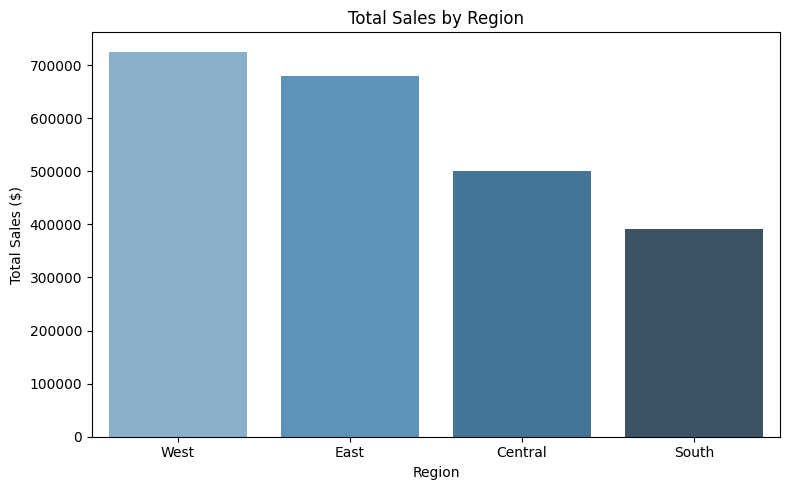

In [4]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_d')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.show()

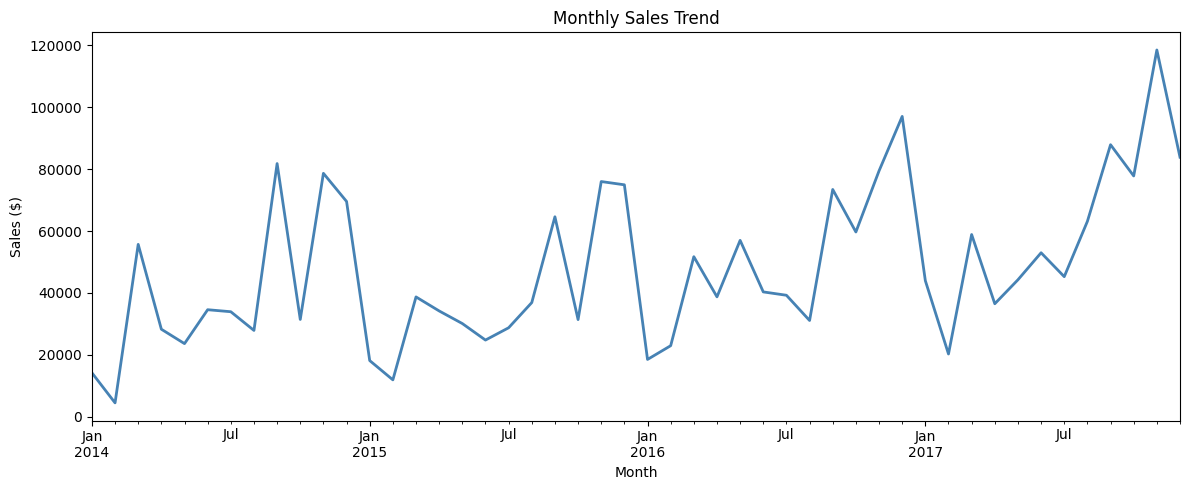

In [5]:
### Monthly sales trend 

df['order_date'] = pd.to_datetime(df['order_date'])
monthly = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

plt.figure(figsize=(12,5))
monthly.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

/var/folders/f6/h_3m2byx0kg5xtg5h0fyj9r80000gn/T/ipykernel_79107/2533827761.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='profit', data=df, palette='Set2')


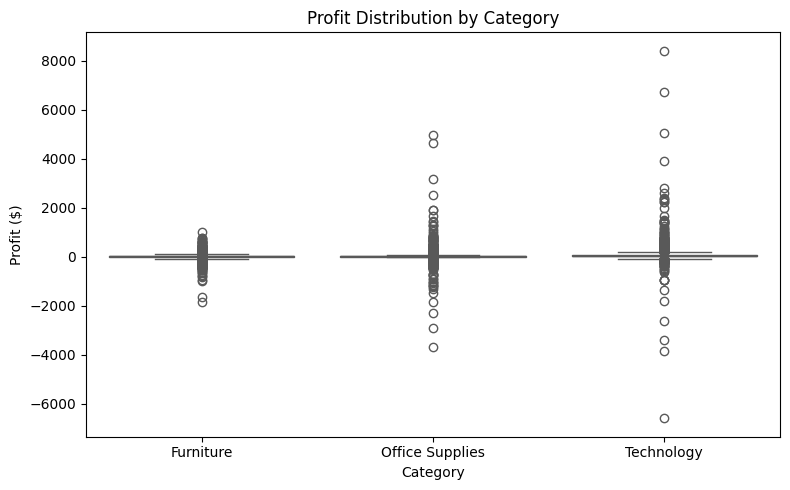

In [6]:
## profit by category 

plt.figure(figsize=(8,5))
sns.boxplot(x='category', y='profit', data=df, palette='Set2')
plt.title('Profit Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('profit_by_category.png')
plt.show()

In [1]:
import sys
print(sys.executable)

/Users/maneeshakillampalli/superstore-venv/bin/python
